In [44]:
import importlib
import sys
from pathlib import Path
SCRIPTS = Path().resolve() / "libraries"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
import post_mcmc
import numpy as np
importlib.reload(post_mcmc)
from gala.coordinates import GreatCircleICRSFrame
import astropy.coordinates as coord
from astropy import units as u
import matplotlib.pyplot as plt
from post_mcmc import plot_form
import copy
import pandas as pd
from scipy import stats
import stream_functions as stream_funcs
import streamTutorial as st
import corner
from astropy import table
from scipy import stats

In [45]:
def get_mem_path(directory):
    import os
    files = os.listdir(directory)
    for file in files:
        if ('0.5%_mem' in file or '50%_mem' in file) and file.endswith('.fits'):
            return os.path.join(directory, file)

mem_path = get_mem_path('/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/runs/C-23-I24_260223_testTrue/')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)

In [46]:
import galstreams
mwsts = galstreams.MWStreams(verbose=False, implement_Off=True)
galstream_=mwsts.get('Sylgr-I21')
fr = galstream_.stream_frame

Initializing galstreams library from master_log... 


In [47]:
desi_data = post_mcmc.load_desi_data(desi_path = '/Users/nasserm/Documents/vscode/data/old_photometry_loa_cleaned_051125.fits', fr=fr, local=True, distance_path = '/Users/nasserm/Documents/vscode/data/rvsdistnn-loa-241126.fits')


desi_data['VGSR'] = stream_funcs.vhel_to_vgsr(
    np.array(desi_data['TARGET_RA']) * u.deg,
    np.array(desi_data['TARGET_DEC']) * u.deg,
    np.array(desi_data['VRAD']) * (u.km / u.s),
).value



desi_data['phi1'], desi_data['phi2'] = stream_funcs.ra_dec_to_phi1_phi2(
    fr,
    np.array(desi_data['TARGET_RA']) * u.deg,
    np.array(desi_data['TARGET_DEC']) * u.deg,
)

RVS distances added


In [48]:
desi_data

,TARGET_RA,TARGET_DEC,FEH,FEH_ERR,LOGG,TARGETID,VRAD,PRIMARY,TEFF,VRAD_ERR,...,dist_mod_err,FLUX_Z,FLUX_R,FLUX_G,EBV,dist_mod_err_right,dist_mod_right,VGSR,phi1,phi2
0,25.159859,32.408638,-0.780013,0.013224,4.598761,39628530270601815,-20.723753,True,6235.724628,0.968186,...,0.080150,172.413254,157.846954,112.274818,0.044945,0.080150,12.672941,119.380481,-168.369897,38.071712
1,24.955285,32.197888,-0.706914,0.039468,4.764995,1152921504619435900,-57.827379,True,3861.818815,1.496343,...,NaN,21.934380,8.946404,2.453177,0.049809,NaN,NaN,82.295318,-168.417655,37.801720
2,24.931222,32.126668,-0.954418,0.011138,4.082105,39628525149358093,-2.709871,True,6288.958057,0.925257,...,0.123923,534.231201,503.059357,372.109680,0.049990,0.123923,12.154305,137.313309,-168.392755,37.730307
3,25.008393,32.097220,0.313138,0.035541,4.821189,1152921504619435964,-39.114523,True,3326.995536,1.479810,...,NaN,30.564667,4.929417,1.287760,0.048915,NaN,NaN,100.663011,-168.302798,37.739167
4,24.851085,32.140174,0.188343,0.037153,4.470738,1152921504619435903,-56.841151,True,3429.081292,1.111625,...,NaN,55.799023,10.561476,2.834843,0.051363,NaN,NaN,83.399512,-168.474895,37.706522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9770103,252.249961,33.326425,-0.821993,0.086836,4.311372,39632946780438706,-33.121636,True,3902.506993,2.917980,...,NaN,15.384500,6.443040,1.869596,0.030400,NaN,NaN,134.311016,80.671987,8.633903
9770104,250.961177,33.295010,-1.470989,0.025182,4.145432,39632946759470577,-55.904753,True,6162.970072,1.325791,...,0.131673,112.015099,104.504715,77.734718,0.026773,0.136928,13.556334,108.713550,79.592628,8.784538
9770105,250.961177,33.295010,-1.470989,0.025182,4.145432,39632946759470577,-55.904753,True,6162.970072,1.325791,...,0.131673,112.015099,104.504715,77.734718,0.026773,0.131673,13.543329,108.713550,79.592628,8.784538
9770106,251.211554,33.305631,-1.715234,0.036413,4.578232,39632946763663809,-90.549281,True,6078.954946,1.945222,...,0.094742,55.116001,49.928703,35.717365,0.030453,0.153665,13.351147,74.627065,79.803053,8.758927


In [49]:
importlib.reload(post_mcmc)
min_dist = np.min(galstream_.track.distance.value)
stream_ = post_mcmc.StreamMembers(min_dist=min_dist, stream_data=stream_data, desi_data = None, stream_run_directory=stream_run_directory, fr=fr, withBHB=False, withRRL=False)

Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


In [50]:
stream_.stream_data

TARGET_RA,TARGET_DEC,FEH,FEH_ERR,LOGG,TARGETID,VRAD,PRIMARY,TEFF,VRAD_ERR,PARALLAX_ERROR,PMDEC_ERROR,PHOT_BP_MEAN_FLUX,PMRA_ERROR,PMRA,PARALLAX,PMDEC,PMRA_PMDEC_CORR,SOURCE_ID,PHOT_RP_MEAN_FLUX,dist_mod,dist_mod_err,FLUX_Z,FLUX_R,FLUX_G,EBV,dist_mod_right,dist_mod_err_right,VGSR,phi1,phi2,stream_prob,stream_prob_em,stream_prob_ep
float64,float64,float64,float64,float64,int64,float64,bool,float64,float64,float32,float64,float64,float64,float64,float64,float64,float32,int64,float64,float64,float64,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64
194.835333695028,44.99860558568336,-2.1730256466200952,0.1995275091972328,4.269222623669716,2305843020613814808,-198.10412316683335,True,6570.092777282447,8.238556422421697,0.15759274,0.13323987891155198,319.99426657820646,0.11664154911505575,-5.797516316145469,0.11298301825479445,0.11208883235620172,0.33416313,1530286367844872704,324.3852480407377,15.262040037571985,0.3283095061779022,29.322529,29.547947,23.208435,0.017549936,15.441227138662818,0.33162016028790536,-126.04119684796908,-0.7692894818784769,0.149142822367811,0.9820380640997874,0.9586301827280186,0.9899320714397456
196.4568130777786,42.049101575752516,-2.7737809902777713,0.32322985562110584,4.086161304157718,2781881959448576,-174.38904716930313,True,6309.924366756073,9.67871854491126,0.2328989,0.16516949505778844,231.8890548410759,0.1632106041917871,-5.9162915330736165,0.48947358902735044,-0.1471097158947069,0.4212974,1527489656940228480,241.78657690578052,15.976039550956212,0.35847026109695435,22.660675,22.015316,17.184544,0.014507677,16.116851895565112,0.7732812920058519,-108.75215740767152,2.39845871068536,-0.0655485642171834,0.9249590756051786,0.83375243068199,0.9623870642676868
193.6394099146827,44.370465996647134,-1.6495583814073158,0.12303167089677443,5.074397420913183,39633153429602902,-220.6052481865945,True,6675.2699409379475,7.256199342890522,0.18198255,0.13796977833357074,352.0677869549835,0.11118393479410753,-5.8364048295682345,0.23821955040184928,-0.14009074856916415,0.6371042,1530197376122449792,356.6262147484603,14.30740737915039,0.13342860341072083,33.33727,32.52053,25.41975,0.027921658,14.55148696899414,0.2478891909122467,-152.74231032788214,-0.5882007590307959,-0.8923553393816197,0.9203837297629229,0.8263694579577445,0.9628372338711648
198.39475641734052,39.235461380936854,-1.8730936185233975,0.2254807223775297,3.852210404986817,2781831426473984,-207.0161306085669,True,6412.523818729742,9.604869524894056,0.23608851,0.17080602600525172,219.1570899088432,0.1704593194123961,-5.605000814739257,0.12451044200422423,0.07574853240494682,0.22791226,1523231046544066048,225.78570255625715,16.34006548545146,0.5683132410049438,20.890305,20.81451,16.179827,0.01204854,16.263770501210434,0.5904381753150051,-146.5574148349465,5.56808961065629,0.11020536312850493,0.9852323314563781,0.976234408039526,0.9908469222914527
198.6980954594682,42.96546095748591,-2.801224242522083,0.1053739441730776,4.265077709870156,39633131560503944,-219.76558754132162,True,6377.806620171932,3.577124248309195,0.12282702,0.10551073864717503,473.07479444249566,0.08894424452913259,-6.148407950096889,0.21233480340097843,0.05058489178158625,0.3464079,1526450343574148224,483.5104545705697,14.841545104980469,0.277218222618103,45.57926,44.643486,35.35905,0.0155572025,14.89218807220459,0.2899371087551117,-146.87565303944382,2.243215855165539,1.817322206902013,0.9978308222505499,0.9943965297349672,0.9990212009479409
193.67190063826294,48.40508466632469,-2.9284217466850286,0.010967220359042186,3.993922427290735,39633224476919248,-210.68157969977358,True,6368.260638399479,3.1931923273575338,0.12615348,0.12030019233966492,412.0085624135261,0.10635550237598995,-5.712192347224745,0.2167568589365107,0.4620133713515009,0.25501096,1555264007852787328,430.7425869153819,14.792465209960938,0.14171600341796875,40.90899,38.9138,30.054377,0.016531577,14.911035537719727,0.0827489048242569,-129.8108195999459,-4.172835063948165

No orbit results found, skipping orbit track plotting
/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/libraries/post_mcmc.py:2696: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



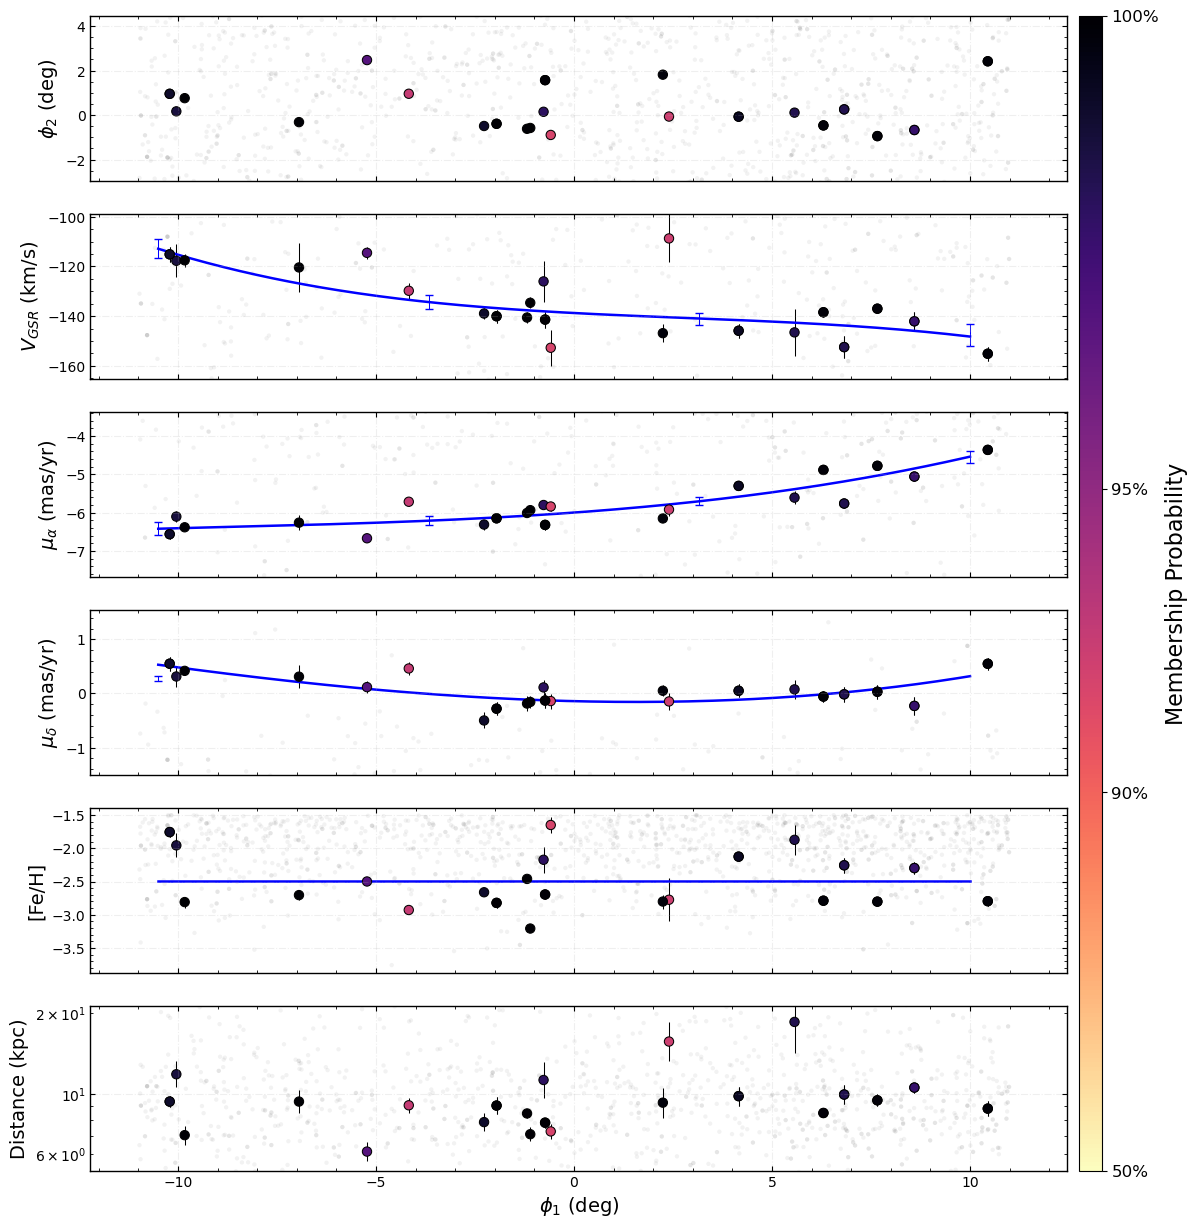

In [51]:
fig,ax = stream_.vis_6_panel(addBackground=True, save_fig=False, show_pm_dispersion=False,
                              show_vgsr_dispersion=False, dist_mod_panel=True, min_prob=0.5, residual=False, show_feh_dispersion=False)

# Look at our posterior distributions

In [52]:
def flatter(obj):
    """
    Flattens mcmc output
    """
    for x in obj:
        if isinstance(x, (list, tuple)):
            yield from flatter(x)
        else:
            yield x
extended_meds = list(flatter(stream_.nested_dict['meds']))

In [53]:
extended_meds

[0.0233351375264407,
 -112.90137952251638,
 -134.3670513573278,
 -140.9683904098478,
 -148.24327952475917,
 0.7654279795629952,
 -2.4939702766486107,
 -0.40481216474107284,
 -6.416941184435743,
 -6.207015258400594,
 -5.6997968915226185,
 -4.534611153249086,
 -0.5629104441692911,
 0.5313932626439731,
 -0.008230808688706535,
 -0.14087645262393034,
 0.31957930989470223,
 -0.9868157212284115,
 141.6362760976951,
 2.2022937747132065,
 -0.9904586886886868,
 -0.06865541198176889,
 -0.7935699919678812,
 0.4782161217476878,
 -18.506251129494558,
 0.734251489140745]

Print indicies for each posterior dimension

In [54]:
for i, name in enumerate(stream_.nested_dict['expanded_param_labels']):
    print(i, name)

0 pstream
1 vgsr1
2 vgsr2
3 vgsr3
4 vgsr4
5 lsigvgsr
6 feh1
7 lsigfeh
8 pmra1
9 pmra2
10 pmra3
11 pmra4
12 lsigpmra
13 pmdec1
14 pmdec2
15 pmdec3
16 pmdec4
17 lsigpmdec
18 bv
19 lsigbv
20 bfeh
21 lsigbfeh
22 bpmra
23 lsigbpmra
24 bpmdec
25 lsigbpmdec


``` 'meds' ``` refers to median posterior values from the MCMC

In [55]:
pick = np.array([2, 9, 14, 6, 5, 7, 12, 17]) # the posterior dimensions we'll vis

labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]
chain = np.vstack([stream_.mcmc_dict['flatchain'][:, p] for p in pick])
mu = {l: extended_meds[stream_.mcmc_dict['extended_param_labels'].index(l)] for l in labels}
std = {l: stream_.mcmc_dict['flatchain'][:, stream_.mcmc_dict['extended_param_labels'].index(l)].std() for l in labels}

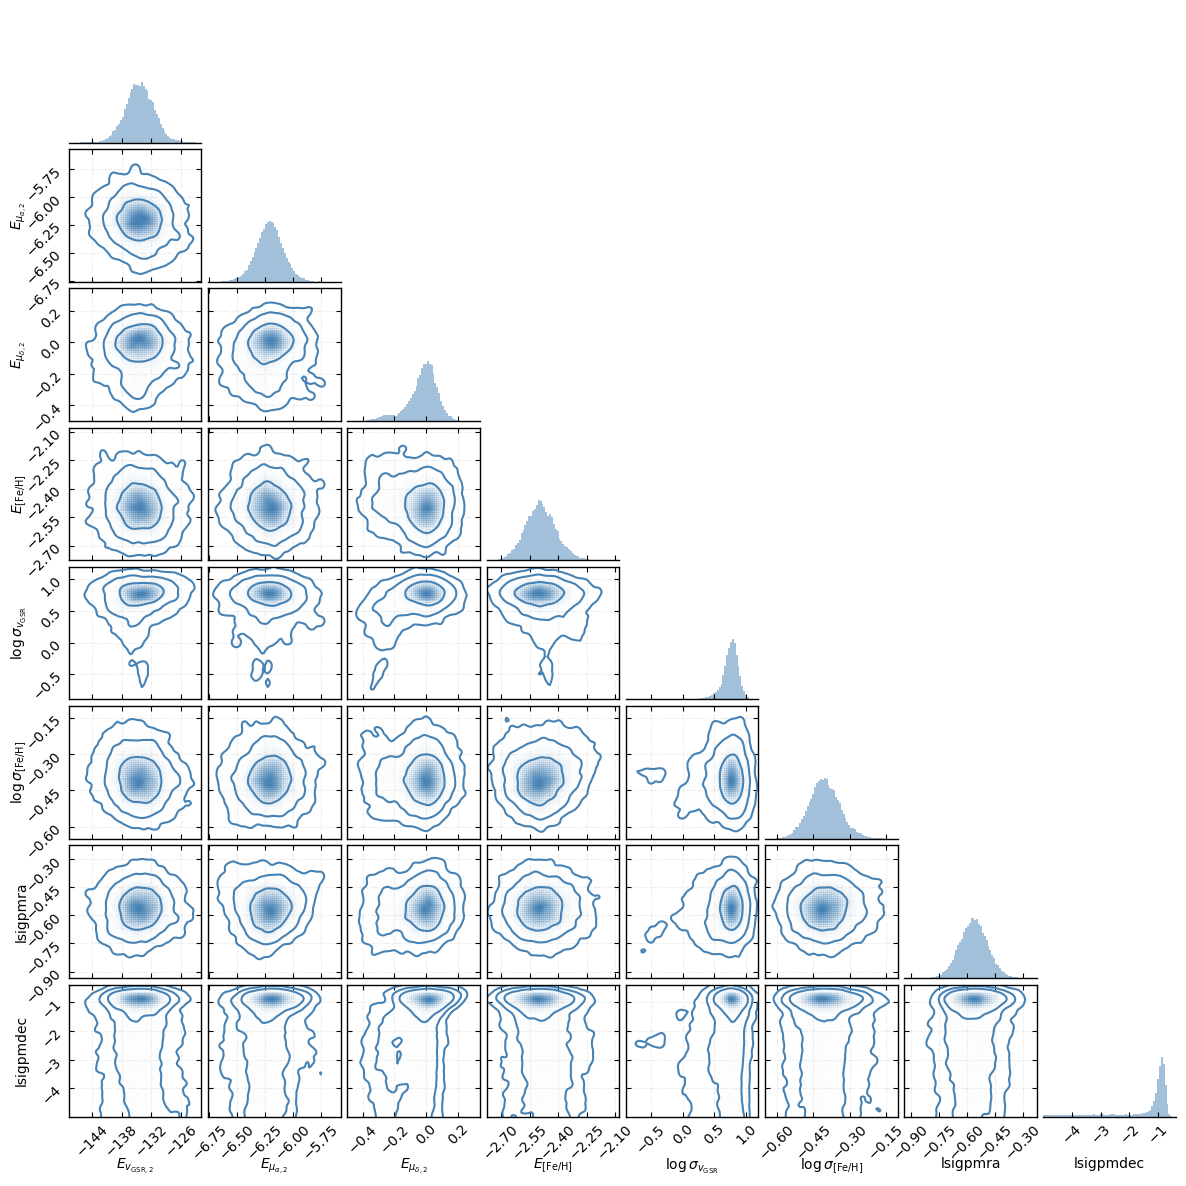

In [56]:
st.set_presentation(False)

def latex_label(lbl):
    if lbl.startswith("vgsr"):
        return rf"$E_{{v_{{\text{{GSR}}, {lbl[4:]}}}}}$"
    if lbl.startswith("pmra"):
        return rf"$E_{{\mu_{{\alpha, {lbl[4:]}}}}}$"
    if lbl.startswith("pmdec"):
        return rf"$E_{{\mu_{{\delta, {lbl[5:]}}}}}$"
    if lbl.startswith("lsigvgsr"):
        return rf"$\log \sigma_{{v_{{\text{{GSR}} {lbl[8:]}}}}}$"
    if lbl.startswith("lsigfeh"):
        return rf"$\log \sigma_{{[\text{{Fe/H}}] {lbl[7:]}}}$"
    if lbl == "feh1":
        return r"$E_{[\text{Fe/H}]}$"
    if lbl == "pstream":
        return r"$f_s$"
    return lbl

corner_labels = [latex_label(lbl) for lbl in labels]
fig = corner.corner(chain.T, color='steelblue', labels=corner_labels, smooth=1.5, bins=70, levels=[0.68, 0.95, .997], plot_datapoints=False,
                    hist_kwargs={"density": True, "color": "steelblue", "histtype": "stepfilled", "alpha": 0.5},
                    )
fig.set_size_inches(1.5 * chain.T.shape[1], 1.5 * chain.T.shape[1])

for ax in fig.axes:
    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    ax.set_ylim(ylim[0] * 1, ylim[1] * 1)
    ax.set_xlim(xlim[0] * 1, xlim[1] * 1)
    ax.tick_params(which="minor", color='1', length=0)

for ax in np.diag(np.array(fig.axes).reshape(chain.T.shape[1], chain.T.shape[1])):
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)



# Single Posterior Realization

In [57]:
phi1_spline_points = stream_.spline_points_dict['phi1_spline_points']

In [58]:
vgsr_func = lambda phi1_arr, meds: stream_funcs.apply_spline(phi1_arr, phi1_spline_points, meds)

def _spline_coeffs_from_draw(draw, prefix, n_spline_points=None):
    """Collect spline coefficients like prefix1..prefixN from one MCMC draw."""
    indexed_coeffs = {}
    for key in draw:
        if not key.startswith(prefix):
            continue
        suffix = key[len(prefix):]
        if suffix.isdigit():
            indexed_coeffs[int(suffix)] = key

    if n_spline_points is None:
        if not indexed_coeffs:
            raise KeyError(
                f"No spline coefficients found for '{prefix}'. "
                f"Available keys include: {sorted(draw.keys())[:10]}..."
            )
        n_spline_points = max(indexed_coeffs)

    coeff_keys = [f"{prefix}{i}" for i in range(1, n_spline_points + 1)]
    missing = [k for k in coeff_keys if k not in draw]
    if missing:
        raise KeyError(
            f"Missing spline coefficients for '{prefix}': {missing}. "
            f"Available keys include: {sorted(draw.keys())[:10]}..."
        )
    return np.array([draw[k] for k in coeff_keys], dtype=float)

def draw_stream(stream_idx, stream_df, n_samples):
    """Draw intrinsic stream stars and `n_samples` noisy realizations.

    Args:
        stream_idx: Indices into `stream_.mcmc_dict['extended_param_labels']`.
        stream_df: DataFrame with `phi1` and measurement-error columns.
        n_samples: Noisy draws per star.

    Returns:
        star_draw_df: Intrinsic draws (one row per star).
        error_draw_df: Noisy draws stacked row-wise.
    """
    pick = stream_idx
    stream_phi1_arr = stream_df['phi1']
    requested_labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]

    rng = np.random.default_rng()
    flatchain = stream_.mcmc_dict['flatchain']
    extended_labels = stream_.mcmc_dict['extended_param_labels']
    extended_label_idx = {label: i for i, label in enumerate(extended_labels)}

    # draw_stream() always evaluates these spline/scatter terms, even if `stream_idx` is a subset.
    required_labels = {'feh1', 'lsigfeh', 'lsigvgsr'}
    for prefix in ('vgsr', 'pmra', 'pmdec'):
        required_labels.update(
            label for label in extended_labels
            if label.startswith(prefix) and label[len(prefix):].isdigit()
        )

    missing_required = [label for label in sorted(required_labels) if label not in extended_label_idx]
    if missing_required:
        raise KeyError(f"draw_stream() is missing required labels: {missing_required}")

    draw_labels = [label for label in extended_labels if label in (set(requested_labels) | required_labels)]
    label_idx = {label: extended_label_idx[label] for label in draw_labels}
    chain_idx = rng.integers(0, flatchain.shape[0])
    theta_row = flatchain[chain_idx]

    n_spline_points = len(stream_.spline_points_dict['phi1_spline_points'])

    star = []
    for _ in stream_phi1_arr:
        draw = {label: theta_row[label_idx[label]] for label in draw_labels}
        star.append(draw)

    star_draw = []
    final_labels = ['VGSR', 'FEH', 'PMRA', 'PMDEC', 'phi1']

    for s, phi1 in zip(star, stream_phi1_arr):
        star_properties = {}
        for labl in final_labels:
            if labl == 'VGSR':
                vgsr_coeffs = _spline_coeffs_from_draw(s, 'vgsr', n_spline_points)
                vgsr = vgsr_func(phi1, vgsr_coeffs)
                star_properties[labl] = rng.normal(vgsr, 10**s['lsigvgsr'])
            elif labl == 'PMRA':
                pmra_coeffs = _spline_coeffs_from_draw(s, 'pmra', n_spline_points)
                pmra = stream_funcs.apply_spline(phi1, stream_.spline_points_dict['phi1_spline_points'], pmra_coeffs)
                star_properties[labl] = rng.normal(pmra, 0.09)
            elif labl == 'PMDEC':
                pmdec_coeffs = _spline_coeffs_from_draw(s, 'pmdec', n_spline_points)
                pmdec = stream_funcs.apply_spline(phi1, stream_.spline_points_dict['phi1_spline_points'], pmdec_coeffs)
                star_properties[labl] = rng.normal(pmdec, 0.09)
            elif labl == 'FEH':
                star_properties[labl] = rng.normal(s['feh1'], 10**s['lsigfeh'])
            else:
                star_properties['phi1'] = phi1
        star_draw.append(star_properties)

    star_draw_df = pd.DataFrame(star_draw)

    err_labels = ['VRAD_ERR', 'FEH_ERR', 'PMRA_ERROR', 'PMDEC_ERROR']
    err_df = stream_df[err_labels]

    error_draw = {}
    for labl, err_labl in zip(final_labels, err_labels):
        mu = np.asarray(star_draw_df[labl], dtype=float)
        sigma = np.asarray(err_df[err_labl], dtype=float)
        error_draw[labl] = rng.normal(loc=mu, scale=sigma, size=(n_samples, mu.size))

    rows = []
    for i, phi1_val in enumerate(star_draw_df['phi1']):
        df = pd.DataFrame({lab: error_draw[lab][:, i] for lab in error_draw})
        df['phi1'] = phi1_val
        rows.append(df)

    error_draw_df = pd.concat(rows, ignore_index=True)

    return star_draw_df, error_draw_df

def sample_err(mu, err, N):
    return np.random.default_rng.normal(loc=mu, scale=err, size=(N, )+mu.shape)

def draw_background(background_idx, background_df, n_samples, reject_df=None):
    """Draw intrinsic background stars and `n_samples` noisy realizations (truncated-normal).

    This matches rejection-sampling from a normal constrained to [low, high],
    but is much faster by drawing directly from scipy.stats.truncnorm.
    """
    pick = background_idx
    phi1_vals = np.asarray(background_df['phi1'], dtype=float)

    # Use whichever catalogue defines the selection window
    window_df = background_df if reject_df is None else reject_df
    bounds = {
        'VGSR': (np.nanmin(window_df['VGSR']), np.nanmax(window_df['VGSR'])),
        'PMRA': (np.nanmin(window_df['PMRA']), np.nanmax(window_df['PMRA'])),
        'PMDEC': (np.nanmin(window_df['PMDEC']), np.nanmax(window_df['PMDEC'])),
        'FEH':  (np.nanmin(window_df['FEH']),  np.nanmax(window_df['FEH'])),
    }

    requested_labels = [stream_.mcmc_dict['extended_param_labels'][p] for p in pick]
    rng = np.random.default_rng()
    flatchain = stream_.mcmc_dict['flatchain']
    extended_labels = stream_.mcmc_dict['extended_param_labels']
    extended_label_idx = {label: i for i, label in enumerate(extended_labels)}

    required_labels = {
        'bv', 'lsigbv',
        'bpmra', 'lsigbpmra',
        'bpmdec', 'lsigbpmdec',
        'bfeh', 'lsigbfeh',
    }
    missing_required = [label for label in sorted(required_labels) if label not in extended_label_idx]
    if missing_required:
        raise KeyError(f"draw_background() is missing required labels: {missing_required}")

    draw_labels = [label for label in extended_labels if label in (set(requested_labels) | required_labels)]
    label_idx = {label: extended_label_idx[label] for label in draw_labels}
    theta_row = flatchain[rng.integers(0, flatchain.shape[0])]
    theta_map = {label: theta_row[label_idx[label]] for label in draw_labels}

    n_stars = phi1_vals.size
    star_draw_df = pd.DataFrame({'phi1': phi1_vals})

    intrinsic_cfg = {
        'VGSR': ('bv', 'lsigbv'),
        'PMRA': ('bpmra', 'lsigbpmra'),
        'PMDEC': ('bpmdec', 'lsigbpmdec'),
        'FEH': ('bfeh', 'lsigbfeh'),
    }

    # Intrinsic background draws (one per star), truncated to window bounds.
    for key, (mu_key, lsig_key) in intrinsic_cfg.items():
        mu = float(theta_map[mu_key])
        sigma = float(10 ** theta_map[lsig_key])
        low, high = bounds[key]
        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError(f"Invalid intrinsic sigma for {key}: {sigma}")
        a = (low - mu) / sigma
        b = (high - mu) / sigma
        star_draw_df[key] = stats.truncnorm.rvs(a=a, b=b, loc=mu, scale=sigma, size=n_stars, random_state=rng)

    err_labels = {
        'VGSR': 'VRAD_ERR',
        'PMRA': 'PMRA_ERROR',
        'PMDEC': 'PMDEC_ERROR',
        'FEH':  'FEH_ERR',
    }
    err_df = background_df[list(err_labels.values())]

    # Measurement draws: shape (n_samples, n_stars) per quantity
    error_draw = {}
    for key, err_name in err_labels.items():
        mu = np.asarray(star_draw_df[key], dtype=float)
        sigma = np.asarray(err_df[err_name], dtype=float)
        low, high = bounds[key]
        if np.any(~np.isfinite(sigma)) or np.any(sigma <= 0):
            raise ValueError(f"Invalid measurement sigma(s) for {key}")
        a = (low - mu) / sigma
        b = (high - mu) / sigma
        error_draw[key] = stats.truncnorm.rvs(
            a=a[np.newaxis, :],
            b=b[np.newaxis, :],
            loc=mu[np.newaxis, :],
            scale=sigma[np.newaxis, :],
            size=(n_samples, n_stars),
            random_state=rng,
        )

    rows = []
    for k in range(n_samples):
        df = pd.DataFrame({key: error_draw[key][k] for key in err_labels})
        df['phi1'] = phi1_vals
        rows.append(df)

    error_draw_df = pd.concat(rows, ignore_index=True)
    return star_draw_df, error_draw_df


In [59]:
# Posterior draws → predictive catalogues
rng = np.random.default_rng(14)
chain = stream_.mcmc_dict['flatchain']
labels = stream_.mcmc_dict['extended_param_labels']
phi1_nodes = np.asarray(stream_.stream_data['phi1'], dtype=float)
phi1_knots = stream_.spline_points_dict['phi1_spline_points']

err_cols = {
    'VGSR': 'VRAD_ERR',
    'PMRA': 'PMRA_ERROR',
    'PMDEC': 'PMDEC_ERROR',
    'FEH': 'FEH_ERR',
}
stream_errors = {col: np.asarray(stream_.stream_data[col], dtype=float) for col in err_cols.values()}

In [60]:
summary_keys = ['VGSR', 'PMRA', 'PMDEC', 'FEH']
summary_labels = [r'$v_{GSR}$ (km/s)', r'$\mu_{\alpha}$ (mas/yr)', r'$\mu_{\delta}$ (mas/yr)', r'[Fe/H] (dex)']

def catalogue_means(df):
    return np.array([np.nanmean(df[key]) for key in summary_keys])


samples_draw, samples_werr = draw_stream(np.arange(1, 16), stream_.stream_data, n_samples=1)
observed = stream_.stream_data.to_pandas()


background_stars = stream_.all_memberships[stream_.all_memberships['stream_prob'] <= 0.5]
background_draw, background_error_draw = draw_background(np.arange(16, 25), background_stars, 1, stream_.all_memberships)

sample_v = pd.concat([samples_draw, background_draw])

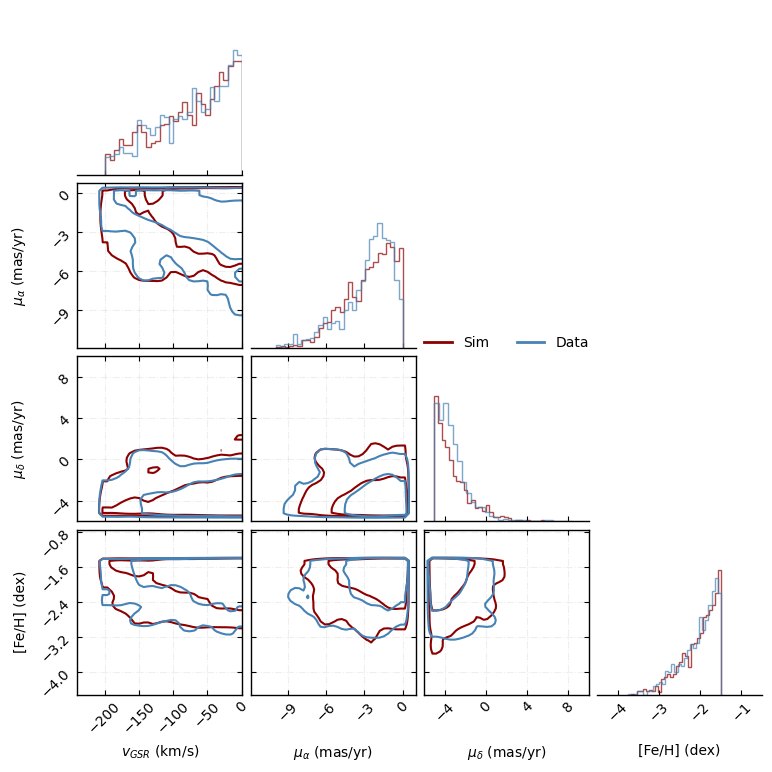

In [61]:
fig = corner.corner(
    sample_v[summary_keys],
    labels=summary_labels,
    color='darkred',
    smooth=1.5,
    bins=30,
    levels=[0.68, 0.95],
    plot_density=False,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "darkred", "histtype": "step", "alpha": 0.7},
)

corner.corner(
    stream_.all_memberships[summary_keys],
    labels=summary_labels,
    color='steelblue',
    smooth=1.5,
    bins=30,
    levels=[0.68, 0.95],
    plot_density=False,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "steelblue", "histtype": "step", "alpha": 0.7},
    fig=fig
)

fig.set_size_inches(2 * len(summary_labels), 2 * len(summary_labels))


axes_grid = np.array(fig.axes).reshape(len(summary_labels), len(summary_labels))

for ax in fig.axes:
    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    axis_scale_y = 1.2
    axies_scale_x = 1.2
    ax.set_ylim(ylim[0]*axis_scale_y, ylim[1]*axis_scale_y if ylim[1]>0 else ylim[1]+0.75)
    ax.set_xlim(xlim[0]*axies_scale_x, xlim[1]*axies_scale_x if xlim[1]>0 else xlim[1]+1)
    ax.tick_params(which="minor", color='1', length=0)

for i, ax in enumerate(np.diag(axes_grid)):

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1]*1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)

axes_grid[2,2].plot([], [], lw=2, c='darkred', label='Sim')
axes_grid[2,2].plot([], [], lw=2, c='steelblue', label='Data')
axes_grid[2,2].legend(frameon=False, bbox_to_anchor=(0.5, 1.2), loc='upper center', ncol=2);

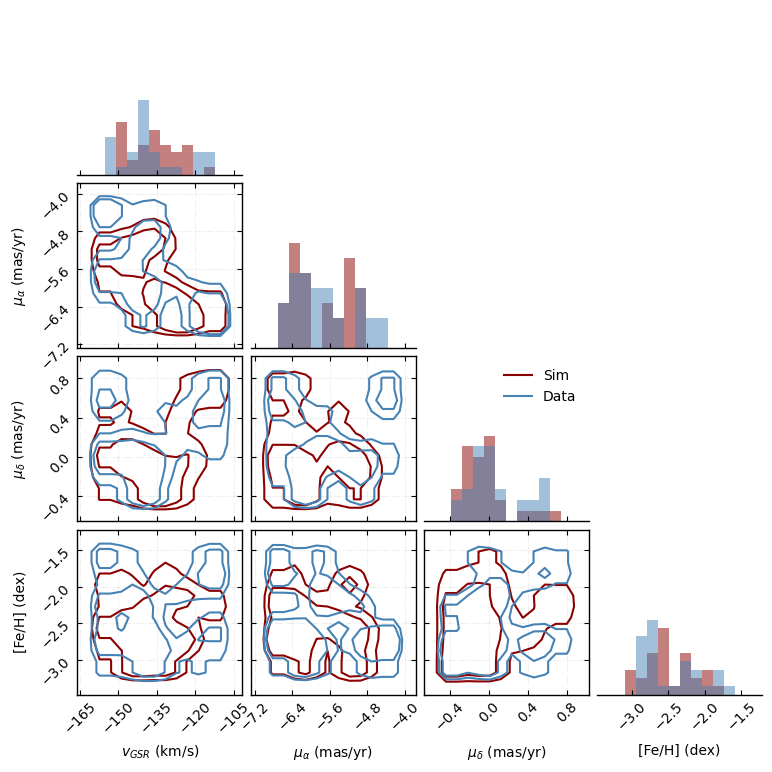

In [62]:
summary_keys = ['VGSR', 'PMRA', 'PMDEC', 'FEH']
summary_labels = [r'$v_{GSR}$ (km/s)', r'$\mu_{\alpha}$ (mas/yr)', r'$\mu_{\delta}$ (mas/yr)', r'[Fe/H] (dex)']
# plt.style.use('dark_background')

def catalogue_means(df):
    return np.array([np.nanmean(df[key]) for key in summary_keys])


_, samples_werr = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)
observed = stream_.stream_data.to_pandas()

sample_ = samples_werr

# Use contour-focused axis limits from central quantiles (shared by sim+data)
q_lo, q_hi = 0.01, 0.99
corner_ranges = []
for key in summary_keys:
    both = pd.concat([samples_werr[key], observed[key]], ignore_index=True).to_numpy()
    lo, hi = np.nanquantile(both, [q_lo, q_hi])
    corner_ranges.append((lo, hi))

fig = corner.corner(
    samples_werr[summary_keys],
    labels=summary_labels,
    color='darkred',
    smooth=1,
    bins=10,
    levels=[0.68, 0.95],
    range=corner_ranges,
    plot_density=False,
    plot_contours=True,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "darkred", "histtype": "stepfilled", "alpha": 0.5},
    data_kwargs={"ms": 2, "alpha": 0.5,
                 "mec": "darkred"},
)

corner.corner(
    observed[summary_keys],
    labels=summary_labels,
    color='steelblue',
    smooth=1,
    bins=10,
    levels=[0.68, 0.95],
    range=corner_ranges,
    plot_density=False,
    plot_contours=True,
    plot_datapoints=False,
    hist_kwargs={"density": False, "color": "steelblue", "histtype": "stepfilled", "alpha": 0.5},
    data_kwargs={"ms": 2, "alpha": 0.5,
                 "mec": "steelblue"},
    fig=fig
)

fig.set_size_inches(2 * len(summary_labels), 2 * len(summary_labels))


axes_grid = np.array(fig.axes).reshape(len(summary_labels), len(summary_labels))

ndim = len(summary_keys)
padding_scale=1.5
for i, ax in enumerate(fig.axes):
    row = i // ndim
    col = i % ndim
    if row == col:  # skip diagonal
        plot_form(ax)
        xlim = ax.get_xlim()
        
        x_center = (xlim[0] + xlim[1]) / 2
        x_range = xlim[1] - xlim[0]
        
        new_x_range = x_range * padding_scale
        
        ax.set_xlim(x_center - new_x_range/2, x_center + new_x_range/2)
        
        ax.tick_params(which="minor", color='1', length=0)
        continue

    plot_form(ax)
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    
    y_center = (ylim[0] + ylim[1]) / 2
    y_range = ylim[1] - ylim[0]
    x_center = (xlim[0] + xlim[1]) / 2
    x_range = xlim[1] - xlim[0]
    
    new_y_range = y_range * padding_scale
    new_x_range = x_range * padding_scale
    
    ax.set_ylim(y_center - new_y_range/2, y_center + new_y_range/2)
    ax.set_xlim(x_center - new_x_range/2, x_center + new_x_range/2)
    
    ax.tick_params(which="minor", color='1', length=0)

for ax in np.diag(axes_grid):
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1]*2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(which="both", direction="in", top=False)
    ax.grid(alpha=0)
    

axes_grid[2,2].plot([], [], c='darkred', label='Sim')
axes_grid[2,2].plot([], [], c='steelblue', label='Data')
axes_grid[2,2].legend(frameon=False)



# Multiple Posterior Realizations

In [63]:
n_draws = 100
ppc_vals_all = None
phi1_index_all = None
ppc_list_all = []

import tqdm

for d in tqdm.tqdm(range(n_draws)):
    _, samples_werr = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)
    _, background_werr = draw_background(np.arange(14, 23), background_stars, 1, stream_.all_memberships)

    mock = pd.concat([samples_werr, background_werr], ignore_index=True)

    g = mock.groupby("phi1")[summary_keys].mean()  # 1 row per phi1 (if phi1 duplicates, this is the intended aggregation)

    if phi1_index_all is None:
        phi1_index_all = g.index
        ppc_vals_all = np.empty((n_draws, len(phi1_index_all), len(summary_keys)), dtype=float)

    g = g.reindex(phi1_index_all)  # keep consistent ordering
    ppc_list_all.append(g)
    ppc_vals_all[d] = g.to_numpy()

mean_all = ppc_vals_all.mean(axis=0)
q16_all, q84_all = np.quantile(ppc_vals_all, [0.16, 0.84], axis=0)
q025_all, q975_all = np.quantile(ppc_vals_all, [0.025, 0.975], axis=0)

_ci_all = pd.concat(
    {
        "mean":     pd.DataFrame(mean_all, index=phi1_index_all, columns=summary_keys),
        "ci_lower": pd.DataFrame(q16_all,  index=phi1_index_all, columns=summary_keys),
        "ci_upper": pd.DataFrame(q84_all,  index=phi1_index_all, columns=summary_keys),
    },
    axis=1,
)

_ci2_all = pd.concat(
    {
        "mean":     pd.DataFrame(mean_all,  index=phi1_index_all, columns=summary_keys),
        "ci_lower": pd.DataFrame(q025_all,  index=phi1_index_all, columns=summary_keys),
        "ci_upper": pd.DataFrame(q975_all,  index=phi1_index_all, columns=summary_keys),
    },
    axis=1,
)



100%|██████████| 100/100 [00:00<00:00, 104.02it/s]


In [64]:
non_members_mask = stream_.all_memberships['stream_prob'] < 0.5
len(stream_.all_memberships[non_members_mask])
# len(stream_.stream_data)

1248

Text(0.5, -0.02, 'Observed quantiles')

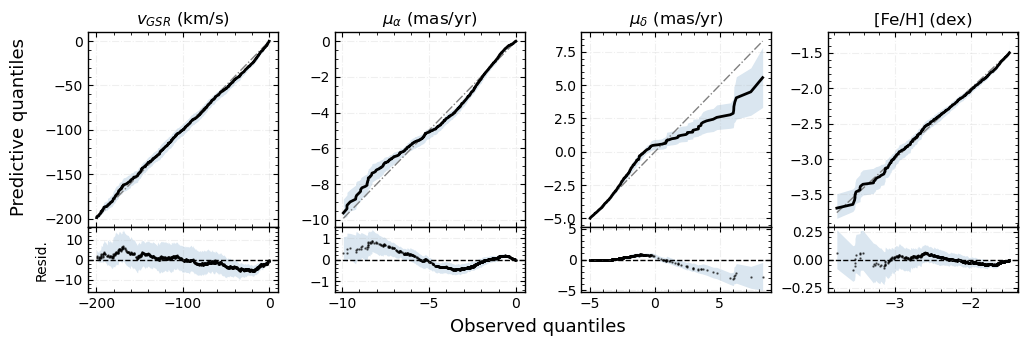

In [66]:
fig = plt.figure(figsize=(16*0.75, 4.5*0.75))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.0, wspace=0.3)

for idx in range(4):

    # --- Extract observed vector ---
    obs_vec = stream_.all_memberships[non_members_mask][summary_keys[idx]].to_numpy()
    obs_sorted = np.sort(obs_vec)
    n_obs = len(obs_sorted)

    # Prepare Q-grid for interpolation (common quantile axis)
    q = np.linspace(0, 1, n_obs)

    # --- Compute predictive quantiles for each posterior draw ---
    ppc_q = []   # will be shape (n_draws, n_obs)

    for mock in ppc_list_all:
        x = mock[summary_keys[idx]].to_numpy()
        x_sorted = np.sort(x)

        # Interpolate predictive distribution to shared q-grid
        ppc_q.append(
            np.interp(q, np.linspace(0, 1, len(x_sorted)), x_sorted)
        )

    ppc_q = np.array(ppc_q)    # (n_draws, n_quantiles)

    # --- Bayesian predictive envelopes ---
    rep_sorted   = np.median(ppc_q, axis=0)
    lower_sorted = np.percentile(ppc_q, 16, axis=0)
    upper_sorted = np.percentile(ppc_q, 84, axis=0)

    lower_sorted2 = np.percentile(ppc_q, 2.5, axis=0)
    upper_sorted2 = np.percentile(ppc_q, 97.5, axis=0)

    # --- residuals ---
    residuals = rep_sorted - obs_sorted

    # --- plot structure preserved exactly as yours ---
    ax_qq = fig.add_subplot(gs[0, idx])
    ax_res = fig.add_subplot(gs[1, idx], sharex=ax_qq)

    # Q-Q line (median predictive)
    ax_qq.plot(obs_sorted, rep_sorted, c='k', lw=2)
    ax_qq.set_title(f'{summary_labels[idx]}')

    # Shaded PPC ribbons
    # ax_qq.fill_between(obs_sorted, lower_sorted, upper_sorted,
    #                    color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_qq.fill_between(obs_sorted, lower_sorted2, upper_sorted2,
                       color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # 1:1 line
    ax_qq.plot([obs_sorted[0], obs_sorted[-1]],
               [obs_sorted[0], obs_sorted[-1]],
               c='0.5', ls='-.', lw=1, zorder=0)

    ax_qq.tick_params(labelbottom=False)
    plot_form(ax_qq)

    # Residual plot
    ax_res.scatter(obs_sorted, residuals, c='k', s=0.5, alpha=0.6)
    ax_res.axhline(0, c='k', ls='--', lw=1)

    # ax_res.fill_between(obs_sorted, lower_sorted - obs_sorted,
    #                     upper_sorted - obs_sorted,
    #                     color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_res.fill_between(obs_sorted, lower_sorted2 - obs_sorted,
                        upper_sorted2 - obs_sorted,
                        color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # Center residual y-axis on 0
    ymin, ymax = ax_res.get_ylim()
    yabs = max(abs(ymin), abs(ymax))
    ax_res.set_ylim(-yabs, yabs)

    plot_form(ax_res)
    if idx == 0:
        ax_res.set_ylabel('Resid.', fontsize=10)

fig.supylabel('Predictive quantiles', x=0.06, y=0.6, fontsize=13)
fig.supxlabel('Observed quantiles', y=-0.02, fontsize=13)


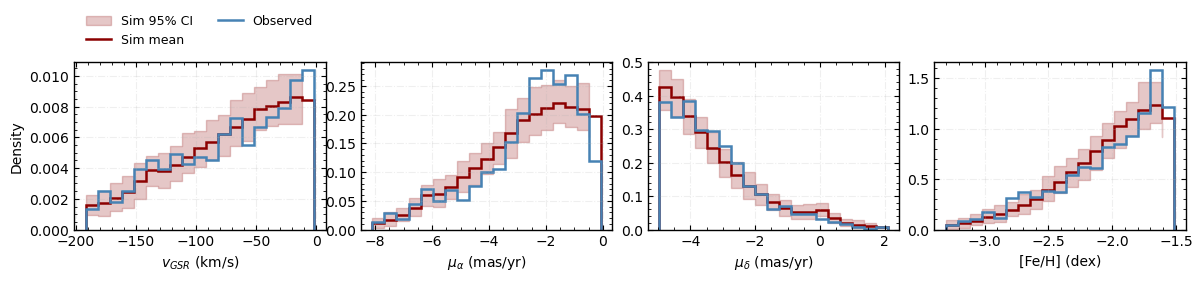

In [67]:
# PPC: 1D histograms with simulated 95% CI band
fig, axes = plt.subplots(1, len(summary_keys), figsize=(16*0.75, 3.6*0.75), constrained_layout=True)

for idx, key in enumerate(summary_keys):
    ax = axes[idx]

    # Observed values
    obs = stream_.all_memberships[key].to_numpy(dtype=float)

    # Simulated values from each posterior predictive draw
    sim_draws = [mock[key].to_numpy(dtype=float) for mock in ppc_list_all]

    # Shared binning using robust limits to avoid extreme outlier-driven axes
    all_vals = np.concatenate([obs] + sim_draws)
    lo, hi = np.nanquantile(all_vals, [0.01, 0.99])
    bins = np.linspace(lo, hi, 20)

    # Histogram for each simulated draw -> posterior predictive uncertainty per bin
    sim_hists = np.array([
        np.histogram(x, bins=bins, density=True)[0]
        for x in sim_draws
    ])

    sim_mean = np.nanmean(sim_hists, axis=0)
    sim_lo = np.nanpercentile(sim_hists, 2.5, axis=0)
    sim_hi = np.nanpercentile(sim_hists, 97.5, axis=0)

    # Observed histogram (same step representation as simulated summaries)
    obs_hist = np.histogram(obs, bins=bins, density=True)[0]

    # Simulated 95% CI band and mean
    ax.stairs(sim_hi, bins, color='none')
    ax.fill_between(
        bins[:-1], sim_lo, sim_hi, step='post', color='darkred', alpha=0.22, label='Sim 95% CI'
    )
    ax.stairs(sim_mean, bins, color='darkred', lw=1.8, label='Sim mean')

    # Observed step curve
    ax.stairs(obs_hist, bins, color='steelblue', lw=1.8, label='Observed')

    ax.set_xlabel(summary_labels[idx])
    if idx == 0:
        ax.set_ylabel('Density')
    plot_form(ax)

axes[0].legend(frameon=False, fontsize=9, bbox_to_anchor=(0, 1.35), loc='upper left', ncol=2)




## Stream Only

In [68]:
n_draws = 100
ppc_vals_stream = None
phi1_index_stream = None
ppc_list_stream = []

import tqdm

for d in tqdm.tqdm(range(n_draws)):
    _, mock = draw_stream(np.arange(1, 14), stream_.stream_data, n_samples=1)

    g = mock.groupby("phi1")[summary_keys].mean()  # 1 row per phi1 (if phi1 duplicates, this is the intended aggregation)

    if phi1_index_stream is None:
        phi1_index_stream = g.index
        ppc_vals_stream = np.empty((n_draws, len(phi1_index_stream), len(summary_keys)), dtype=float)

    g = g.reindex(phi1_index_stream)  # keep consistent ordering
    ppc_list_stream.append(g)
    ppc_vals_stream[d] = g.to_numpy()

mean_stream = ppc_vals_stream.mean(axis=0)
q16_stream, q84_stream = np.quantile(ppc_vals_stream, [0.16, 0.84], axis=0)
q025_stream, q975_stream = np.quantile(ppc_vals_stream, [0.025, 0.975], axis=0)

_ci_stream = pd.concat(
    {
        "mean":     pd.DataFrame(mean_stream, index=phi1_index_stream, columns=summary_keys),
        "ci_lower": pd.DataFrame(q16_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_upper": pd.DataFrame(q84_stream,  index=phi1_index_stream, columns=summary_keys),
    },
    axis=1,
)

_ci2_stream = pd.concat(
    {
        "mean":     pd.DataFrame(mean_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_lower": pd.DataFrame(q025_stream,  index=phi1_index_stream, columns=summary_keys),
        "ci_upper": pd.DataFrame(q975_stream,  index=phi1_index_stream, columns=summary_keys),
    },
    axis=1,
)



100%|██████████| 100/100 [00:00<00:00, 166.72it/s]


Text(0.5, -0.02, 'Observed quantiles')

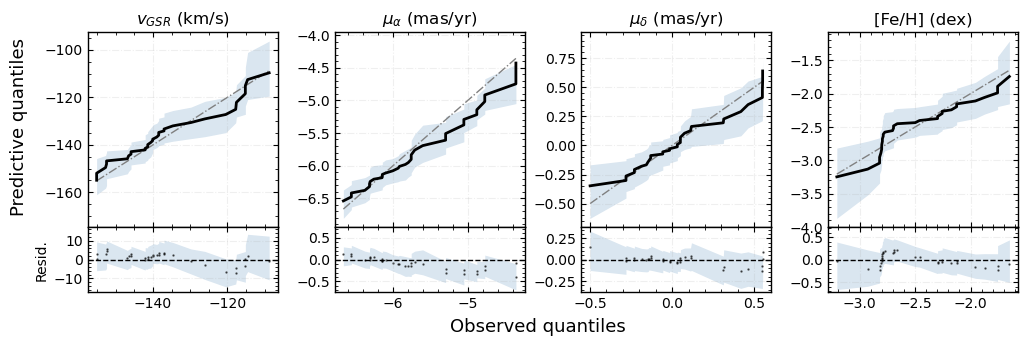

In [69]:
fig = plt.figure(figsize=(16*0.75, 4.5*0.75))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.0, wspace=0.3)

for idx in range(4):

    # --- Extract observed vector ---
    obs_vec = stream_.stream_data[summary_keys[idx]]
    obs_sorted = np.sort(obs_vec)
    n_obs = len(obs_sorted)

    # Prepare Q-grid for interpolation (common quantile axis)
    q = np.linspace(0, 1, n_obs)

    # --- Compute predictive quantiles for each posterior draw ---
    ppc_q = []   # will be shape (n_draws, n_obs)

    for mock in ppc_list_stream:
        x = mock[summary_keys[idx]].to_numpy()
        x_sorted = np.sort(x)

        # Interpolate predictive distribution to shared q-grid
        ppc_q.append(
            np.interp(q, np.linspace(0, 1, len(x_sorted)), x_sorted)
        )

    ppc_q = np.array(ppc_q)    # (n_draws, n_quantiles)

    # --- Bayesian predictive envelopes ---
    rep_sorted   = np.median(ppc_q, axis=0)
    lower_sorted = np.percentile(ppc_q, 16, axis=0)
    upper_sorted = np.percentile(ppc_q, 84, axis=0)

    lower_sorted2 = np.percentile(ppc_q, 2.5, axis=0)
    upper_sorted2 = np.percentile(ppc_q, 97.5, axis=0)

    # --- residuals ---
    residuals = rep_sorted - obs_sorted

    # --- plot structure preserved exactly as yours ---
    ax_qq = fig.add_subplot(gs[0, idx])
    ax_res = fig.add_subplot(gs[1, idx], sharex=ax_qq)

    # Q-Q line (median predictive)
    ax_qq.plot(obs_sorted, rep_sorted, c='k', lw=2)
    ax_qq.set_title(f'{summary_labels[idx]}')

    # Shaded PPC ribbons
    # ax_qq.fill_between(obs_sorted, lower_sorted, upper_sorted,
    #                    color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_qq.fill_between(obs_sorted, lower_sorted2, upper_sorted2,
                       color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # 1:1 line
    ax_qq.plot([obs_sorted[0], obs_sorted[-1]],
               [obs_sorted[0], obs_sorted[-1]],
               c='0.5', ls='-.', lw=1, zorder=0)

    ax_qq.tick_params(labelbottom=False)
    plot_form(ax_qq)

    # Residual plot
    ax_res.scatter(obs_sorted, residuals, c='k', s=0.5, alpha=0.6)
    ax_res.axhline(0, c='k', ls='--', lw=1)

    # ax_res.fill_between(obs_sorted, lower_sorted - obs_sorted,
    #                     upper_sorted - obs_sorted,
    #                     color='steelblue', alpha=0.3, zorder=0, linewidth=0)
    ax_res.fill_between(obs_sorted, lower_sorted2 - obs_sorted,
                        upper_sorted2 - obs_sorted,
                        color='steelblue', alpha=0.2, zorder=0, linewidth=0)

    # Center residual y-axis on 0
    ymin, ymax = ax_res.get_ylim()
    yabs = max(abs(ymin), abs(ymax))
    ax_res.set_ylim(-yabs, yabs)

    plot_form(ax_res)
    if idx == 0:
        ax_res.set_ylabel('Resid.', fontsize=10)

fig.supylabel('Predictive quantiles', x=0.06, y=0.6, fontsize=13)
fig.supxlabel('Observed quantiles', y=-0.02, fontsize=13)


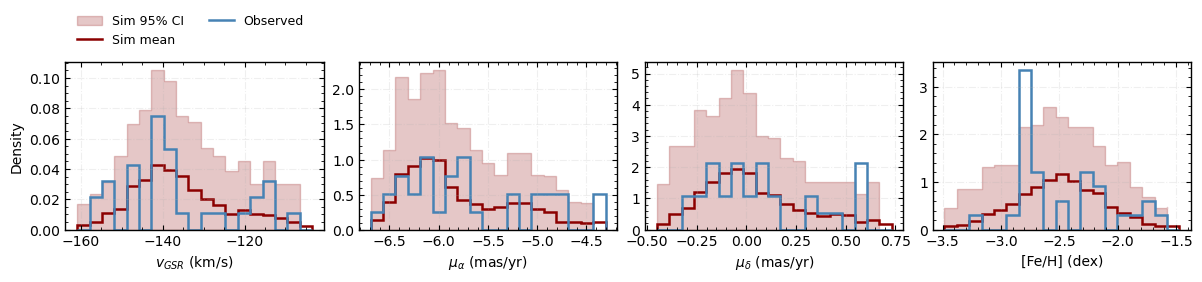

In [70]:
# PPC: 1D histograms with simulated 95% CI band
fig, axes = plt.subplots(1, len(summary_keys), figsize=(16*0.75, 3.6*0.75), constrained_layout=True)

for idx, key in enumerate(summary_keys):
    ax = axes[idx]

    # Observed values
    obs = stream_.stream_data[key]

    # Simulated values from each posterior predictive draw
    sim_draws = [mock[key].to_numpy(dtype=float) for mock in ppc_list_stream]

    # Shared binning using robust limits to avoid extreme outlier-driven axes
    all_vals = np.concatenate([obs] + sim_draws)
    lo, hi = np.nanquantile(all_vals, [0.01, 0.99])
    bins = np.linspace(lo, hi, 20)

    # Histogram for each simulated draw -> posterior predictive uncertainty per bin
    sim_hists = np.array([
        np.histogram(x, bins=bins, density=True)[0]
        for x in sim_draws
    ])

    sim_mean = np.nanmean(sim_hists, axis=0)
    sim_lo = np.nanpercentile(sim_hists, 2.5, axis=0)
    sim_hi = np.nanpercentile(sim_hists, 97.5, axis=0)

    # Observed histogram (same step representation as simulated summaries)
    obs_hist = np.histogram(obs, bins=bins, density=True)[0]

    # Simulated 95% CI band and mean
    ax.stairs(sim_hi, bins, color='none')
    ax.fill_between(
        bins[:-1], sim_lo, sim_hi, step='post', color='darkred', alpha=0.22, label='Sim 95% CI'
    )
    ax.stairs(sim_mean, bins, color='darkred', lw=1.8, label='Sim mean')

    # Observed step curve
    ax.stairs(obs_hist, bins, color='steelblue', lw=1.8, label='Observed')

    ax.set_xlabel(summary_labels[idx])
    if idx == 0:
        ax.set_ylabel('Density')
    plot_form(ax)

axes[0].legend(frameon=False, fontsize=9, bbox_to_anchor=(0, 1.35), loc='upper left', ncol=2)


